In [1]:
# installing quickdraw, importing other libs
from quickdraw import QuickDrawDataGroup

In [3]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pyplot as plt
import numpy as np

import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

In [5]:
# defining food categories for training/testing
with open('food.txt', 'r') as file:
    # Read text, strip trailing newlines, and split by comma
    CATEGORIES = file.read().strip().split(', ')
SAMPLES = 3000

In [7]:
images = []
labels = []
label_map = {}

label_index = 0
for category in CATEGORIES:
    group = QuickDrawDataGroup(category, max_drawings=SAMPLES)
    label_map.update({category:label_index})
    label_index = label_index+1
    for drawing in group.drawings:
        img = np.array(drawing.image.convert('L').resize((128, 128))) # update to 128x128 import
        images.append(img)
        labels.append(category)

loading apple drawings
load complete
loading banana drawings
load complete
loading bread drawings
load complete
loading broccoli drawings
load complete
loading cake drawings
load complete
loading carrot drawings
load complete
loading cookie drawings
load complete
loading donut drawings
load complete
loading grapes drawings
load complete
loading hamburger drawings
load complete
loading ice cream drawings
load complete
loading pizza drawings
load complete
loading popsicle drawings
load complete
loading strawberry drawings
load complete
loading watermelon drawings
load complete


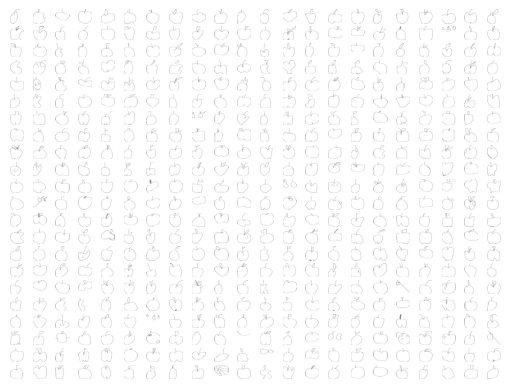

In [9]:
for i in range(484):
  plt.subplot(22, 22, i+1)
  plt.imshow(images[i], cmap='gray')
  plt.axis('off')

(-0.5, 127.5, 127.5, -0.5)

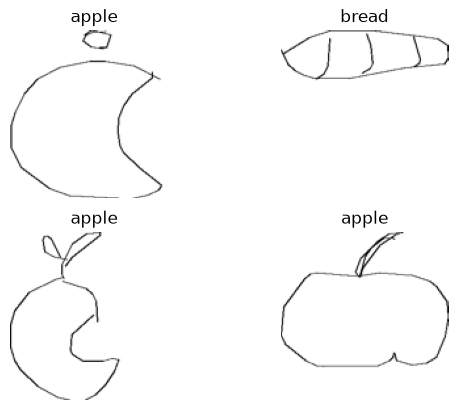

In [12]:
plt.subplot(2, 2, 1)
plt.imshow(images[1000], cmap='gray')
plt.title(labels[1000])
plt.axis('off')


plt.subplot(2, 2, 2)
plt.imshow(images[7000], cmap='gray')
plt.title(labels[7000])
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(images[2500], cmap='gray')
plt.title(labels[2500])
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(images[300], cmap='gray')
plt.title(labels[300])
plt.axis('off')

In [9]:
from sklearn.model_selection import train_test_split

In [11]:
# partitioning dataset
X=np.array(images) / 255.0 # standardize to (0,1)
y=np.array(labels)
y = np.array([label_map[l] for l in labels])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [13]:
# converting from original data format to PyTorch tensors
# Float for pixel values (input), int/long for output values (class labels)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [15]:
# add channel dimension of 1 to for correct CNN processing format (batch size, channel, height, width)
X_train = X_train.unsqueeze(1)
X_test = X_test.unsqueeze(1)

In [17]:
# Assign train and test dataset
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [19]:
# Provide CNN input in small batches
# smaller = more precise but longer training
# longer = faster processing but fewer updates (may need to update lr)
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [21]:
# view data format
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([128, 1, 128, 128])
torch.Size([128])


In [23]:
# define CNN
class FoodCNN(nn.Module):

    def __init__(self):
        super().__init__()
      # 2d convolution layer to process image
        self.conv1 = nn.Conv2d(
            in_channels=1, # grayscale (not color)
            out_channels=32, # 32 features to be detected (arbitrary)
            kernel_size=3, # 3x3 region scanning (arbitrary)
            padding=1 # border to allow for processing of edge elements??? (arbitrary)
        )

        self.conv2 = nn.Conv2d(
            in_channels=32, # prev output 32 features
            out_channels=64,
            kernel_size=3,
            padding=1
        )
        # helps to reduce computational expenses while retaining essential features and no over-dependnig on location
        self.pool = nn.MaxPool2d(2) # reduce feature map size from 16x16 to 8x8 by taking max of 2x2 blocks in feature map, stride 2, kernel size 2 (arbitrary)

        # embedding layer - dim of 128
        self.embedding = nn.Linear(64 * 32 * 32, 128)

        # use extracted features to classify image
        self.fc = nn.Linear(128, 15)

    # forward pass
    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        # convert feature map to vector for fully connected layer processing
        x = torch.flatten(x, 1)

        embedding = F.relu(self.embedding(x))

        result = self.fc(embedding)

        return result, embedding

In [25]:
model = FoodCNN()
# runs on cpu
device = torch.device("cpu")

model.to(device)

FoodCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (embedding): Linear(in_features=65536, out_features=128, bias=True)
  (fc): Linear(in_features=128, out_features=15, bias=True)
)

In [27]:
# calculates loss
criterion = nn.CrossEntropyLoss()

In [29]:
# modify model weights while training
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001 # arbitrary
)


In [31]:
epochs = 7 # arbitrary, # iterations

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        # reset gradients to prev adjustments don't confound current required adjustment
        optimizer.zero_grad()

        outputs, embeddings = model(images)
        # calculate loss
        loss = criterion(outputs, labels)
        # backpropagation to calculate gradient
        loss.backward()
        # adjust weight based on backpropagation
        optimizer.step()
        # add up loss over all batches
        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}, Loss = {running_loss/len(train_loader):.4f}"
    )

Epoch 1, Loss = 1.4837
Epoch 2, Loss = 0.6529
Epoch 3, Loss = 0.4640
Epoch 4, Loss = 0.3373
Epoch 5, Loss = 0.2313
Epoch 6, Loss = 0.1515
Epoch 7, Loss = 0.0888


In [33]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs, embeddings = model(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 81.61%


In [59]:
from PIL import Image
import torch
import torchvision.transforms as transforms

image_path = "grapes_good.png"

# Load fresh image every time
image = Image.open(image_path).convert("L")

print("Loading:", image_path)
print("Original size:", image.size)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

image = transform(image)
image = image.unsqueeze(0).to(device)

print("Tensor shape:", image.shape)
print("Mean:", image.mean().item())
print("Min:", image.min().item())
print("Max:", image.max().item())

model.eval()

with torch.no_grad():
    output, embeddings = model(image)
    prediction = torch.argmax(output, dim=1)

print("Predicted class:", prediction.item())


Loading: grapes_good.png
Original size: (256, 256)
Tensor shape: torch.Size([1, 1, 128, 128])
Mean: 0.9717010259628296
Min: 0.01568627543747425
Max: 1.0
Predicted class: 8


In [61]:
label_map

{'apple': 0,
 'banana': 1,
 'bread': 2,
 'broccoli': 3,
 'cake': 4,
 'carrot': 5,
 'cookie': 6,
 'donut': 7,
 'grapes': 8,
 'hamburger': 9,
 'ice cream': 10,
 'pizza': 11,
 'popsicle': 12,
 'strawberry': 13,
 'watermelon': 14}

In [63]:
torch.save(model.state_dict(), 'foodcnn.pth')

In [65]:
model.load_state_dict(torch.load("foodcnn.pth", map_location=device))
model = model.to(device)
model.eval()

FoodCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (embedding): Linear(in_features=65536, out_features=128, bias=True)
  (fc): Linear(in_features=128, out_features=15, bias=True)
)

In [67]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [69]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs, embeddings = model(images)

        # outputs shape: [batch_size, 15]
        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())


# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [71]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_map.keys()
    )
)

              precision    recall  f1-score   support

       apple       0.86      0.87      0.86       600
      banana       0.91      0.81      0.85       600
       bread       0.76      0.78      0.77       600
    broccoli       0.87      0.79      0.83       600
        cake       0.88      0.87      0.87       600
      carrot       0.80      0.80      0.80       600
      cookie       0.75      0.74      0.75       600
       donut       0.77      0.90      0.83       600
      grapes       0.69      0.86      0.76       600
   hamburger       0.92      0.91      0.91       600
   ice cream       0.87      0.80      0.84       600
       pizza       0.80      0.75      0.77       600
    popsicle       0.91      0.89      0.90       600
  strawberry       0.79      0.78      0.78       600
  watermelon       0.72      0.69      0.71       600

    accuracy                           0.82      9000
   macro avg       0.82      0.82      0.82      9000
weighted avg       0.82   

In [73]:
from sklearn.metrics import confusion_matrix

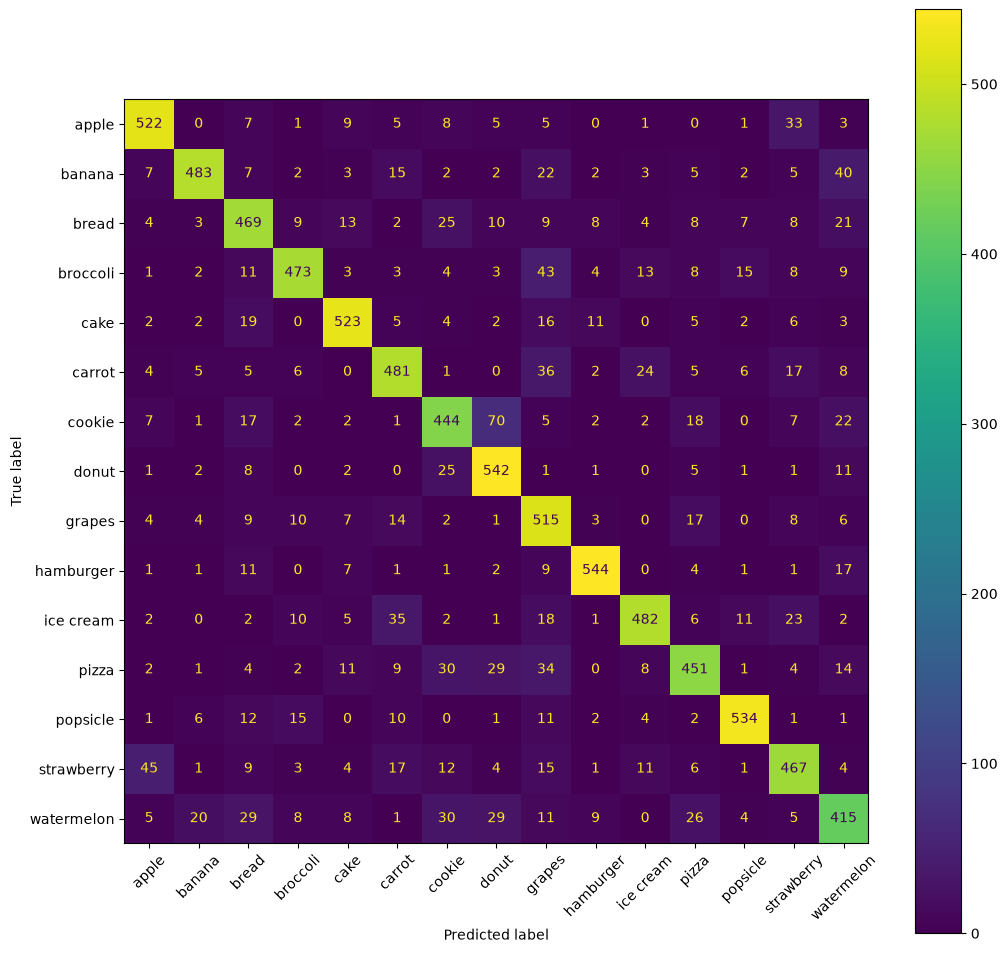

In [75]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_map.keys()

)

fig, ax = plt.subplots(figsize=(12, 12))

disp.plot(

    xticks_rotation=45,
    ax=ax,
    values_format="d"
)

plt.show()

In [77]:
all_embeddings = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs, embeddings = model(images)

        # normalize embeddings before storing
        #embeddings = F.normalize(embeddings, dim=1)

        all_embeddings.append(embeddings)
        all_labels.append(labels)


all_embeddings = torch.cat(all_embeddings, dim=0)
all_labels = torch.cat(all_labels, dim=0)


In [274]:
#with torch.no_grad():
#    output, embedding = model(images)

#print(torch.isnan(embedding).any())

tensor(False)


In [79]:
centroid_per_class = []

for class_id in range(15):
    # Get embeddings for this class
    class_embeddings = all_embeddings[all_labels == class_id]

    # Shuffle so chunks are random
    perm = torch.randperm(len(class_embeddings))
    class_embeddings = class_embeddings[perm]

    # 1 centroid
    centroid_1 = class_embeddings.mean(dim=0)

    # 5 centroids
    centroid_5 = [
        chunk.mean(dim=0)
        for chunk in torch.chunk(class_embeddings, 5)
    ]

    # 10 centroids
    centroid_10 = [
        chunk.mean(dim=0)
        for chunk in torch.chunk(class_embeddings, 10)
    ]

    centroid_per_class.append((centroid_1, centroid_5, centroid_10))

In [81]:
# concatenate centroids for each centroid num/class 
centroids_1 = torch.stack([x[0] for x in centroid_per_class])


centroids_5 = torch.stack(
    [c for x in centroid_per_class for c in x[1]]
)


centroids_10 = torch.stack(
    [c for x in centroid_per_class for c in x[2]]
)


In [115]:
print(centroids_1.shape)
print(centroids_5.shape)
print(centroids_10.shape)

torch.Size([15, 128])
tensor([[0.0000, 0.1635, 0.0000,  ..., 0.0000, 0.2183, 0.1198],
        [0.0000, 0.1683, 0.0000,  ..., 0.0000, 0.2239, 0.1229],
        [0.0000, 0.1623, 0.0000,  ..., 0.0000, 0.2213, 0.1173],
        ...,
        [0.0000, 0.1458, 0.0000,  ..., 0.0000, 0.1827, 0.1199],
        [0.0000, 0.1494, 0.0000,  ..., 0.0000, 0.1760, 0.1242],
        [0.0000, 0.1539, 0.0000,  ..., 0.0000, 0.1685, 0.1218]])
tensor([[0.0000, 0.1619, 0.0000,  ..., 0.0000, 0.2216, 0.1202],
        [0.0000, 0.1650, 0.0000,  ..., 0.0000, 0.2150, 0.1194],
        [0.0000, 0.1690, 0.0000,  ..., 0.0000, 0.2210, 0.1185],
        ...,
        [0.0000, 0.1459, 0.0000,  ..., 0.0000, 0.1843, 0.1262],
        [0.0000, 0.1403, 0.0000,  ..., 0.0000, 0.1686, 0.1203],
        [0.0000, 0.1673, 0.0000,  ..., 0.0000, 0.1682, 0.1231]])


In [83]:
import numpy as np

# 1 centroid per class
np.savez_compressed(
    "food_1.npz",
    centroids=centroids_1.cpu().numpy()
)

# 5 centroids per class
np.savez_compressed(
    "food_5.npz",
    centroids=centroids_5.cpu().numpy()
)

# 10 centroids per class
np.savez_compressed(
    "food_10.npz",
    centroids=centroids_10.cpu().numpy()
)

In [85]:
centroids_1 = torch.from_numpy(np.load("food_1.npz")["centroids"])
centroids_5 = torch.from_numpy(np.load("food_5.npz")["centroids"])
centroids_10 = torch.from_numpy(np.load("food_10.npz")["centroids"])



# normalize
centroids_1 = F.normalize(centroids_1, dim=1)
centroids_5 = F.normalize(centroids_5, dim=1)
centroids_10 = F.normalize(centroids_10, dim=1)

In [87]:
print(centroids_1.shape)
print(centroids_5.shape)
print(centroids_10.shape)


torch.Size([15, 128])
torch.Size([75, 128])
torch.Size([150, 128])


In [89]:
print(torch.norm(centroids_1, dim=1)[:5])


tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [99]:
def get_centroid_similarities(
    embedding,
    class_id,
    centroids_1,
    centroids_5,
        centroids_10

):

    # Normalize embedding
    embedding = F.normalize(embedding, dim=1)


    # 1 centroid
    class_centroid_1 = centroids_1[class_id].unsqueeze(0)

    similarity_1 = (
        embedding @ class_centroid_1.T
    ).item()


   # 5 centroids
    start_5 = class_id * 5
    end_5 = start_5 + 5

    class_centroids_5 = centroids_5[start_5:end_5]

    similarities_5 = (
        embedding @ class_centroids_5.T
    )

    average_similarity_5 = similarities_5.mean().item()


   # 10 centroids
    start_10 = class_id * 10
    end_10 = start_10 + 10

    class_centroids_10 = centroids_10[start_10:end_10]

    similarities_10 = (
        embedding @ class_centroids_10.T
    )

    average_similarity_10 = similarities_10.mean().item()



    return (
        similarity_1,
        average_similarity_5,
        average_similarity_10
    )


In [101]:
from PIL import ImageOps

In [135]:
# computing cosine similarity for each bad/good image to its true class
results = []

model.eval()

for category, class_id in label_map.items():

    for quality in ["good", "bad"]:

        filename = f"{category}_{quality}.png"

        image = Image.open(filename).convert('L').resize((128, 128))
        image = np.array(image)

        # Convert [0,255] numpy array → [0,1] tensor
        image = torch.from_numpy(image).float() / 255.0

        # Add channel + batch dimensions
        image = image.unsqueeze(0).unsqueeze(0).to(device)


        with torch.no_grad():
            _, embedding = model(image)


        similarities = get_centroid_similarities(
            embedding,
            class_id,
            centroids_1,
            centroids_5,
            centroids_10
        )


        results.append([
            filename,
            *similarities
        ])


In [125]:
import pandas as pd

In [137]:
report = pd.DataFrame(
    results,
    columns=[
        "File Name",
        "1 Centroid Similarity",
        "Average 5 Centroid Similarity",
        "Average 10 Centroid Similarity"
    ]
)

print(report)

              File Name  1 Centroid Similarity  Average 5 Centroid Similarity  \
0        apple_good.png               0.564197                       0.564077   
1         apple_bad.png               0.532597                       0.532479   
2       banana_good.png               0.620175                       0.619915   
3        banana_bad.png               0.634647                       0.634379   
4        bread_good.png               0.461475                       0.461089   
5         bread_bad.png               0.571357                       0.570924   
6     broccoli_good.png               0.709712                       0.709456   
7      broccoli_bad.png               0.528758                       0.528547   
8         cake_good.png               0.843271                       0.843003   
9          cake_bad.png               0.661702                       0.661493   
10      carrot_good.png               0.485747                       0.485445   
11       carrot_bad.png     

In [132]:
report.sort_values(by='1 Centroid Similarity')

,File Name,1 Centroid Similarity,Average 5 Centroid Similarity,Average 10 Centroid Similarity
25,popsicle_bad.png,0.414563,0.414418,0.414247
11,carrot_bad.png,0.451244,0.450958,0.450776
4,bread_good.png,0.461475,0.461089,0.460679
10,carrot_good.png,0.485747,0.485445,0.485225
24,popsicle_good.png,0.519475,0.519298,0.519091
13,cookie_bad.png,0.520289,0.520092,0.519875
26,strawberry_good.png,0.527056,0.526877,0.526702
7,broccoli_bad.png,0.528758,0.528547,0.528282
1,apple_bad.png,0.532597,0.532479,0.532372
12,cookie_good.png,0.562643,0.562421,0.562176


In [ ]:
# Um

In [140]:
import gradio as gr

In [193]:
def all_category_cossim(inputpic):
    results = []
    model.eval()
    image = inputpic.convert('L').resize((128, 128))
    image = np.array(image)
    # Convert [0,255] numpy array → [0,1] tensor
    image = torch.from_numpy(image).float() / 255.0
    
            # Add channel + batch dimensions
    image = image.unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
                _, embedding = model(image)
    for category, class_id in label_map.items():
    
            similarities = get_centroid_similarities(
                embedding,
                class_id,
                centroids_1,
                centroids_5,
                centroids_10
            )
    
    
            results.append([
                category,
                *similarities
            ])
    report = pd.DataFrame(results,columns=["File Name","1 Centroid Similarity","Average 5 Centroid Similarity","Average 10 Centroid Similarity"])
    report = report.sort_values(by='1 Centroid Similarity', ascending = False)
    return report


In [195]:
def process_image(edit_data):
    # edit_data contains 'background', 'layers', and 'composite'
    
    return all_category_cossim(edit_data["composite"])

demo = gr.Interface(
    fn=process_image,
    inputs=gr.ImageEditor(type="pil"),
    outputs=gr.Dataframe()
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7871
* To create a public link, set `share=True` in `launch()`.
